In [1]:
import os as os
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from scipy.signal import get_window
from gwpy.timeseries import TimeSeriesDict
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

# Import user defined files
from bethLISA.lisa_glitch_simulation.plotting import plot_all_four
from scripts.lpsd import lpsd
# from scripts.psdAndPlot import psd_and_plot_hor

import scripts.runCommands
importlib.reload(scripts.runCommands)
from scripts.runCommands import run_make_and_inject

# Note: if you change a file, but the change is not reflected when you run the notebook,
# Then, just restart the kernel 
# alternatively, use the importlib.reload function

from scripts.wosa import wosa
from scripts.lpsd import lpsd, lpsd_wosa
from scripts.logpsd import logpsd
from scripts.plot import plot
from scripts.readTdi import readTdi, getTdiPath
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution, normalized_psd_residual
plt.rcParams['text.usetex'] = False


/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17280, 17280, 10368, 6220, 3732, 2239, 1343, 806, 483, 290, 174, 104, 62, 37, 22, 13]
fk_list: [4.6296296296296294e-05, 4.6296296296296294e-05, 7.716049382716049e-05, 0.00012861736334405144, 0.00021436227224008573, 0.0003573023671281822, 0.0005956813104988831, 0.0009925558312655087, 0.0016563146997929607, 0.002758620689655172, 0.004597701149425287, 0.007692307692307693, 0.012903225806451613, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

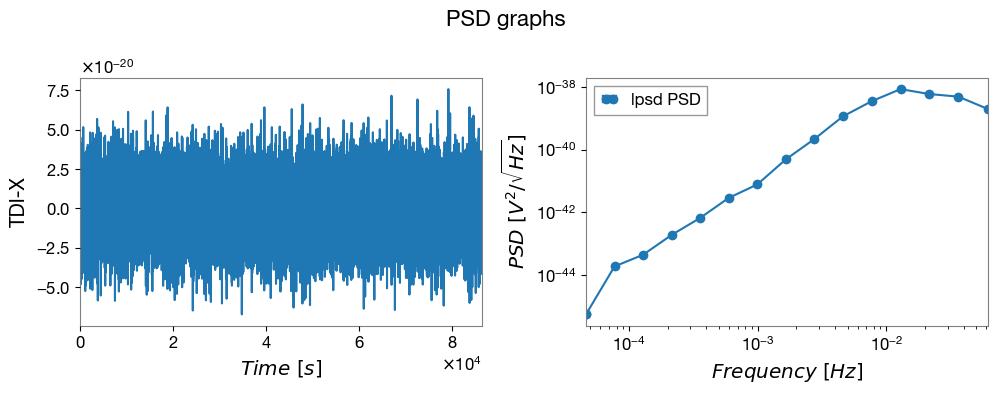

In [2]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_orig_logpsd, psd_orig_logpsd, _ = logpsd(
    x=data_orig, 
    fs=fs, 
    overlap=0, 
    L1=17280
)

f_median, psd_median, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# # Plot the original psd for no reason 
# plot(
#     data=data_orig,
#     t=t, 
#     f=f_orig, 
#     psd= [psd_orig, psd_median],
#     labels= ["mean PSD", "median PSD"],
#     title="TDI-X", 
#     bigtitle="PSD graphs",
#     f_lims = [(fs / nperseg), (fs / 2.0)]
# )

# plot(
#     data=data_orig,
#     t=t, 
#     f=f_orig, 
#     psd= [psd_orig, psd_median],
#     labels= ["mean PSD", "median PSD"],
#     title="TDI-X", 
#     bigtitle="PSD graphs",
#     f_lims = [(fs / nperseg), f_orig[-1]]
# )

plot(
    data=data_orig,
    t=t, 
    f=f_orig_logpsd, 
    psd= [psd_orig_logpsd],
    labels= ["lpsd PSD"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_logpsd[0], f_orig_logpsd[-1]],
    logpsd=True
)

In [3]:
f_orig_lpsd, psd_orig_lpsd, _, _ = lpsd(
    x=data_orig,
    fs=fs,
    fmin=fs/len(data_orig), 
    fmax=fs/2,
    Kdes = 100,
    Kmin = 1
)

f_orig_lpsd_2, psd_orig_lpsd_2, _, _ = lpsd_wosa(
    x=data_orig, 
    fs=fs,
    fmin=fs/len(data_orig), 
    fmax=fs/2,
    W_des=100, 
    W_min=1, 
    xi=0.5,
    Jdes=1000,
    wosa_kwargs=dict(method="mean")   # whatever options your wosa supports
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

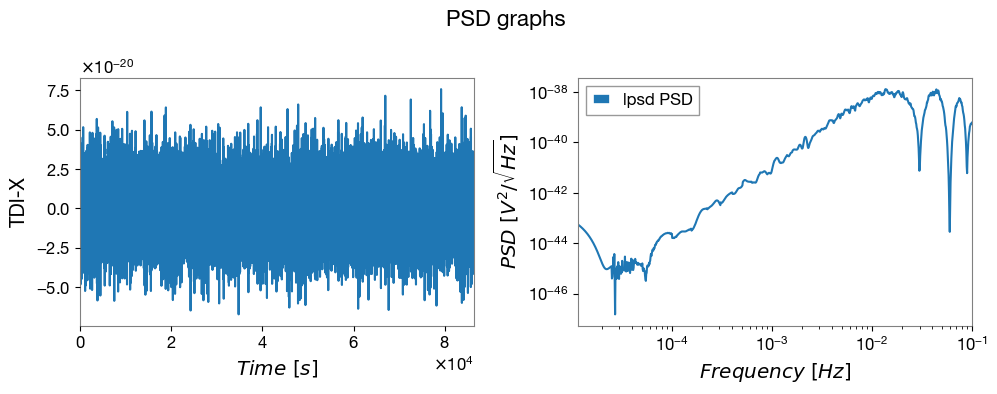

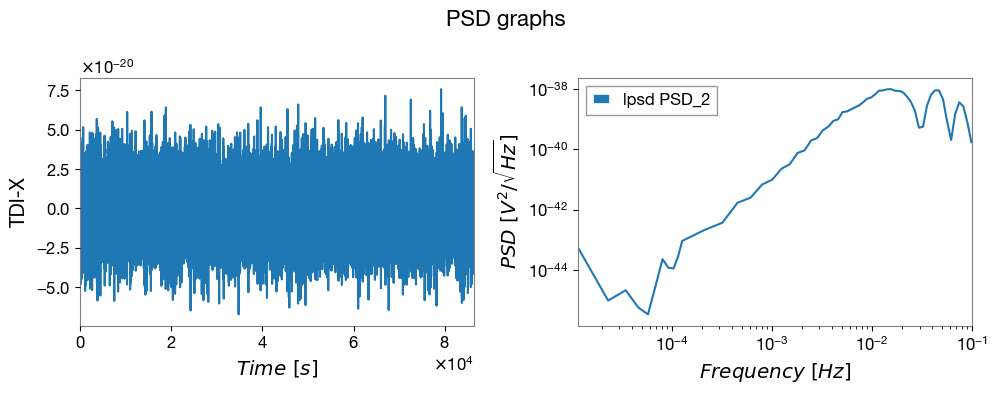

In [4]:
plot(
    data=data_orig,
    t=t, 
    f=f_orig_lpsd, 
    psd= [psd_orig_lpsd],
    labels= ["lpsd PSD"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_lpsd[0], (fs / 2.0)]
)

plot(
    data=data_orig,
    t=t, 
    f=f_orig_lpsd_2, 
    psd= [psd_orig_lpsd_2],
    labels= ["lpsd PSD_2"],
    title="TDI-X", 
    bigtitle="PSD graphs",
    f_lims = [f_orig_lpsd_2[0], (fs / 2.0)]
)

In [10]:
print(psd_orig_lpsd)
print(psd_orig_lpsd.size)

[5.45164734e-44 5.30290128e-44 5.15514258e-44 ... 5.28676410e-40
 5.70673066e-40 5.95386007e-40]
1000


In [11]:
print(f_orig_lpsd_2)
print(f_orig_lpsd_2.size)

[1.15740741e-05 2.31481481e-05 3.47222222e-05 4.62962963e-05
 5.78703704e-05 6.94444444e-05 8.10185185e-05 9.25925926e-05
 1.04166667e-04 1.15740741e-04 1.27314815e-04 2.11809956e-04
 3.20801782e-04 4.54939944e-04 6.14684353e-04 8.00385375e-04
 1.01224978e-03 1.25062880e-03 1.51552947e-03 1.80707466e-03
 2.12554599e-03 2.47096914e-03 2.84340862e-03 3.24261021e-03
 3.66904944e-03 4.12256418e-03 4.60333341e-03 5.11223927e-03
 5.64843230e-03 6.21181258e-03 6.80882750e-03 7.46242227e-03
 8.17926815e-03 8.96358188e-03 9.82565084e-03 1.07690471e-02
 1.18053165e-02 1.29416801e-02 1.41839162e-02 1.55444604e-02
 1.70369977e-02 1.86763420e-02 2.04781438e-02 2.24583418e-02
 2.46322548e-02 2.70132072e-02 2.96106098e-02 3.24677527e-02
 3.55927527e-02 3.90410285e-02 4.28146134e-02 4.69812801e-02
 5.15267346e-02 5.65267346e-02 6.20822902e-02 6.81428963e-02
 7.48095629e-02 8.22169703e-02 9.02169703e-02 9.89126225e-02]
60


In [8]:
dx = 5
no_glitch_integral = np.trapz(np.abs(data_orig[6000-20: 6000+20]), dx=dx)
print(no_glitch_integral)

1.9935007723480114e-18


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

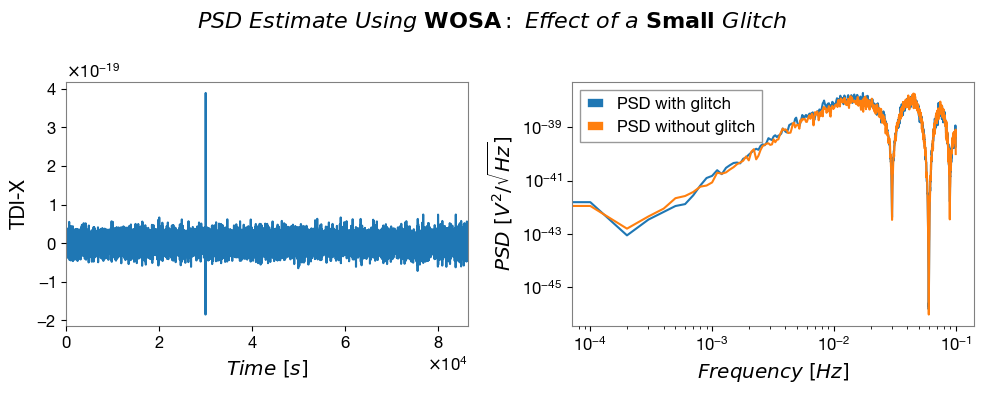

In [7]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$",
)

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

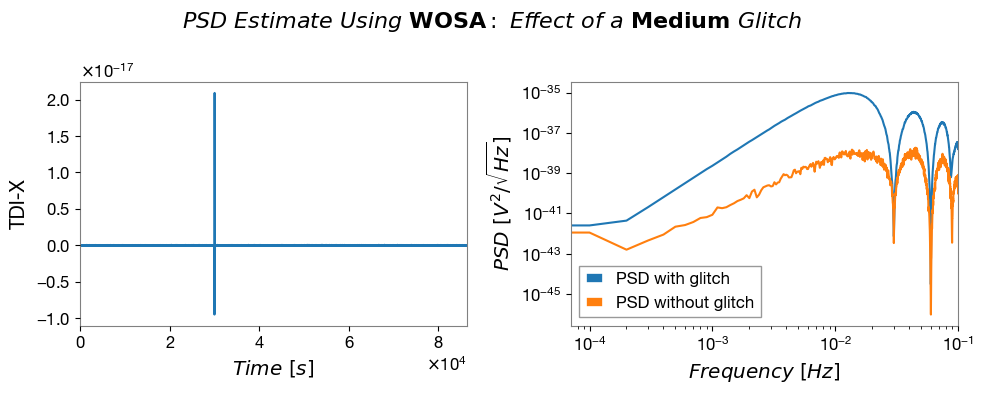

In [8]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    f_lims = [f_mean[0], f_mean[-1]],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

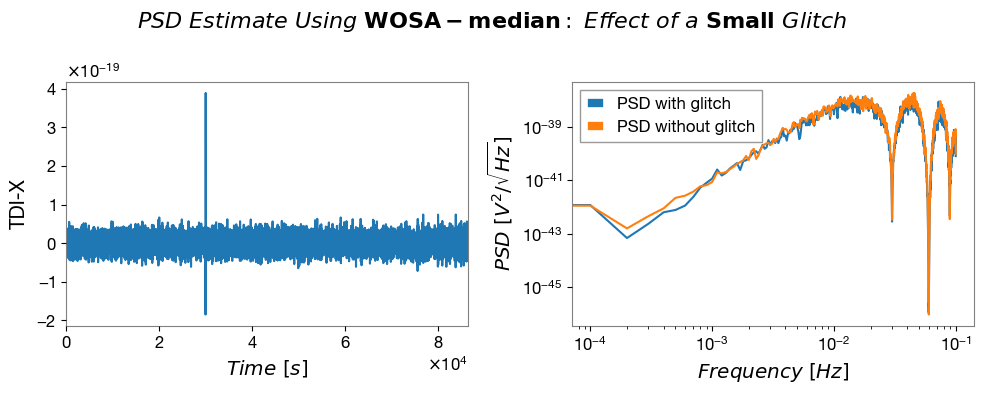

In [9]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_median, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA-median}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$",
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

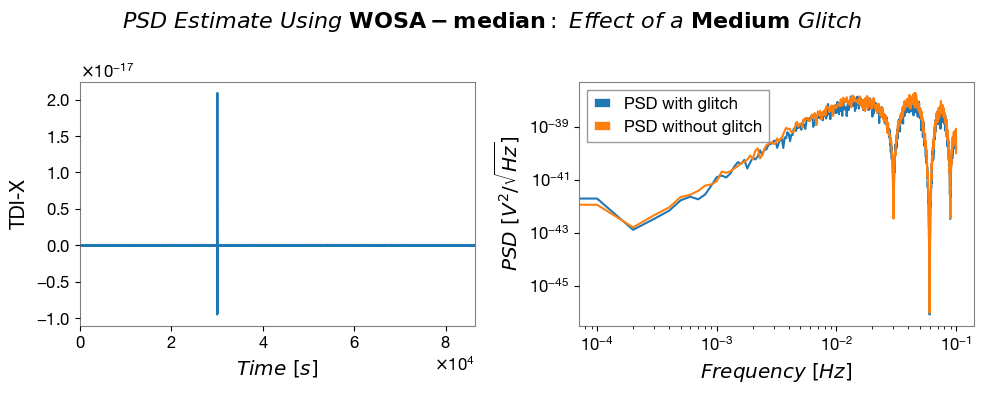

In [10]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_median, psd_orig],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    # bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{WOSA-median}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$",
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

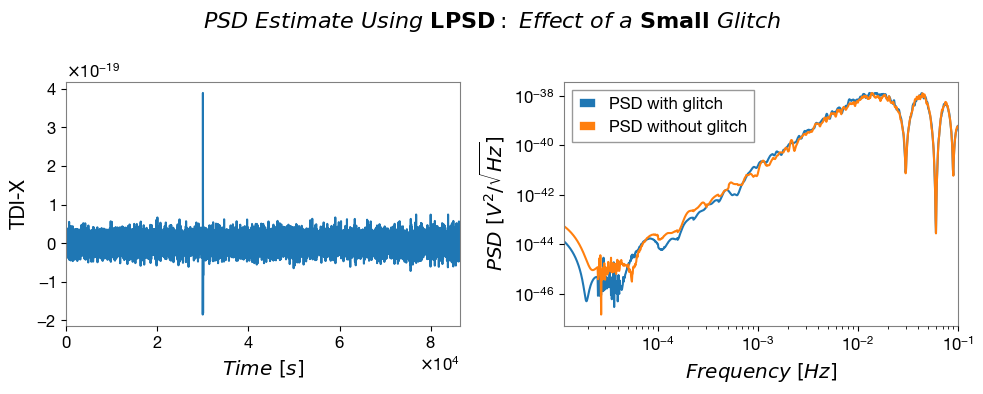

In [12]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_lpsd, psd_lpsd, _, _ = lpsd(
    x=data,
    fs=fs
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_lpsd, 
    f_lims = [f_lpsd[0], fs/2.0],
    psd= [psd_lpsd, psd_orig_lpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LPSD}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

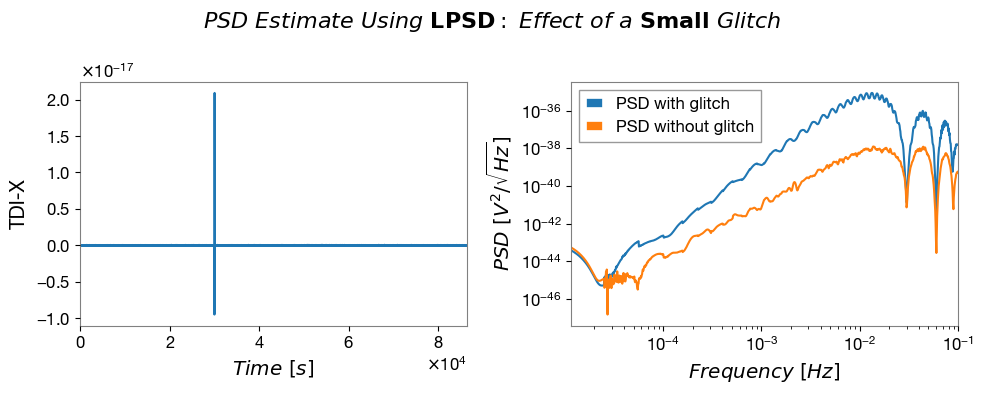

In [14]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_lpsd, psd_lpsd, _, _ = lpsd(
    x=data,
    fs=fs
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_lpsd, 
    f_lims = [f_lpsd[0], fs/2.0],
    psd= [psd_lpsd, psd_orig_lpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LPSD}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$"
)

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17280, 17280, 10368, 6220, 3732, 2239, 1343, 806, 483, 290, 174, 104, 62, 37, 22, 13]
fk_list: [4.6296296296296294e-05, 4.6296296296296294e-05, 7.716049382716049e-05, 0.00012861736334405144, 0.00021436227224008573, 0.0003573023671281822, 0.0005956813104988831, 0.0009925558312655087, 0.0016563146997929607, 0.002758620689655172, 0.004597701149425287, 0.007692307692307693, 0.012903225806451613, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

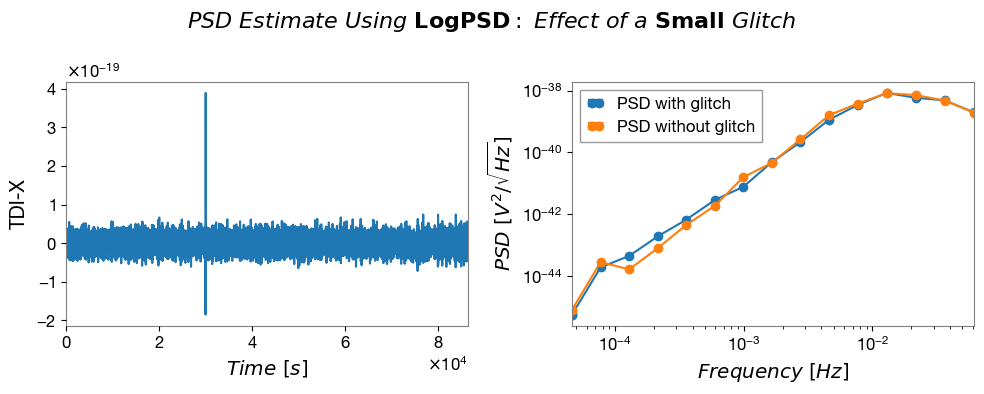

In [15]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_0.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_logpsd, psd_logpsd, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17280
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_logpsd, 
    psd= [psd_orig_logpsd, psd_logpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    f_lims = [f_logpsd[0], f_logpsd[-1]],
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LogPSD}:\ Effect\ of\ a\ \mathbf{Small}\ Glitch$",
    logpsd = True
)

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17280, 17280, 10368, 6220, 3732, 2239, 1343, 806, 483, 290, 174, 104, 62, 37, 22, 13]
fk_list: [4.6296296296296294e-05, 4.6296296296296294e-05, 7.716049382716049e-05, 0.00012861736334405144, 0.00021436227224008573, 0.0003573023671281822, 0.0005956813104988831, 0.0009925558312655087, 0.0016563146997929607, 0.002758620689655172, 0.004597701149425287, 0.007692307692307693, 0.012903225806451613, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

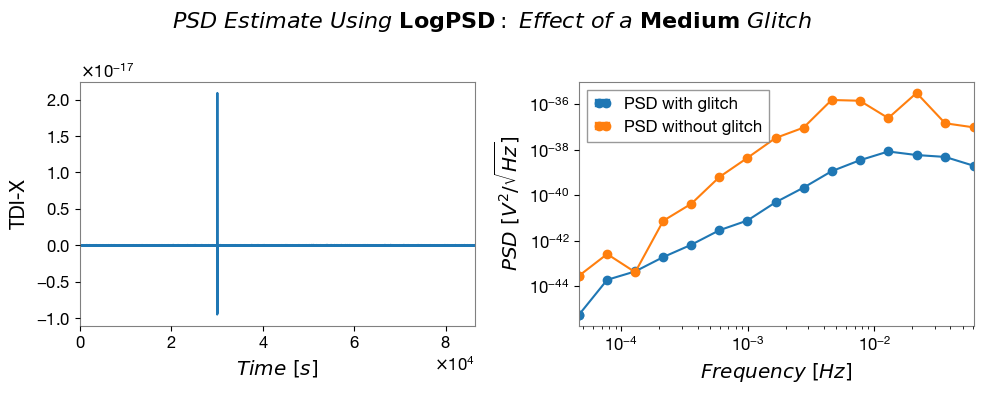

In [ ]:
# 1) Read the TDI time series
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 2000
f_logpsd, psd_logpsd, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17280
) 

# Plot the original psd for no reason 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_logpsd, 
    psd= [psd_orig_logpsd, psd_logpsd],
    labels= ["PSD with glitch", "PSD without glitch"],
    title="TDI-X", 
    f_lims = [f_logpsd[0], f_logpsd[-1]],
    bigtitle=r"$PSD\ Estimate\ Using\ \mathbf{LogPSD}:\ Effect\ of\ a\ \mathbf{Medium}\ Glitch$",
    logpsd = True
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

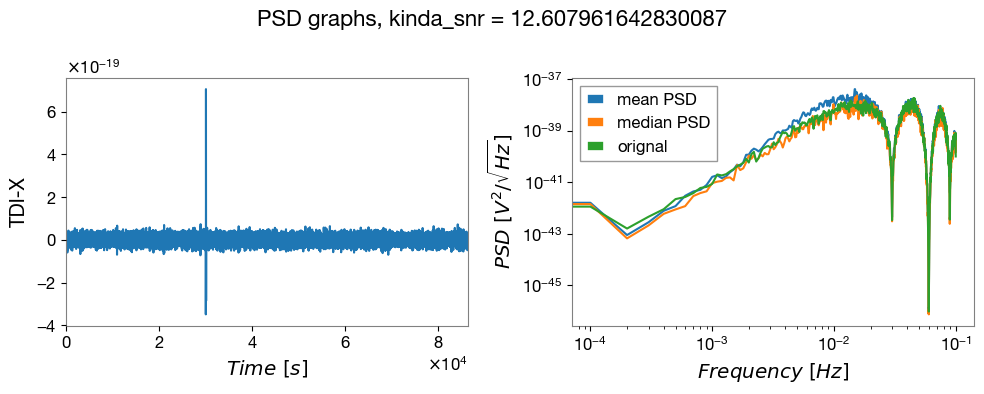

In [17]:
tdi_path = getTdiPath('glitch_2.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

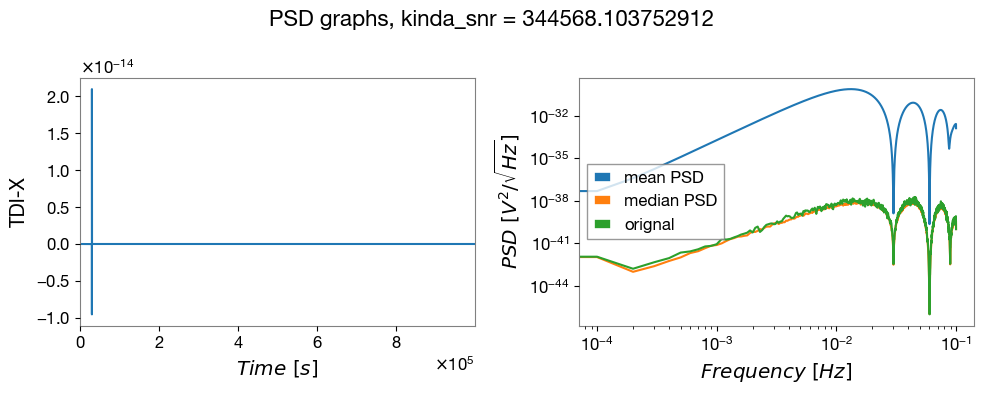

In [19]:
tdi_path = getTdiPath('glitch_8.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

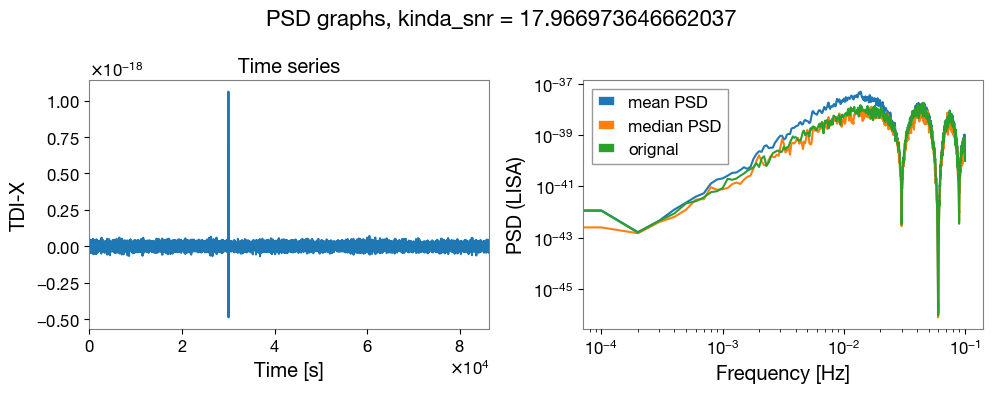

In [ ]:
tdi_path = getTdiPath('glitch_3.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

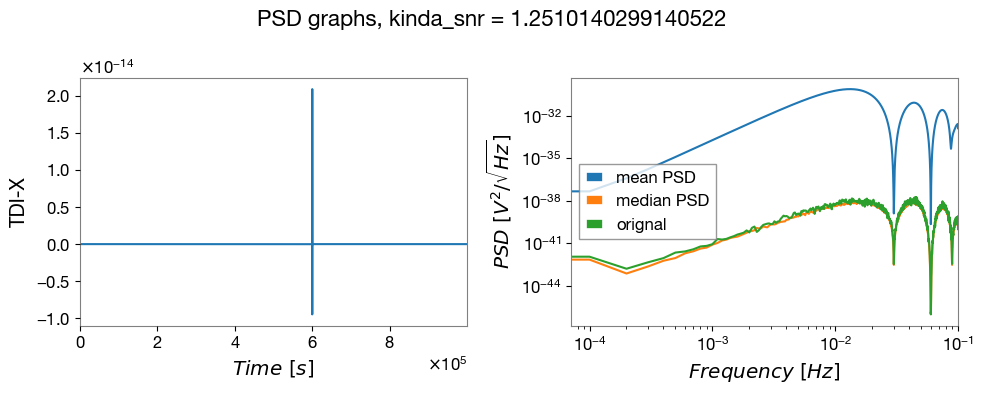

In [21]:
tdi_path = getTdiPath('glitch_9.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

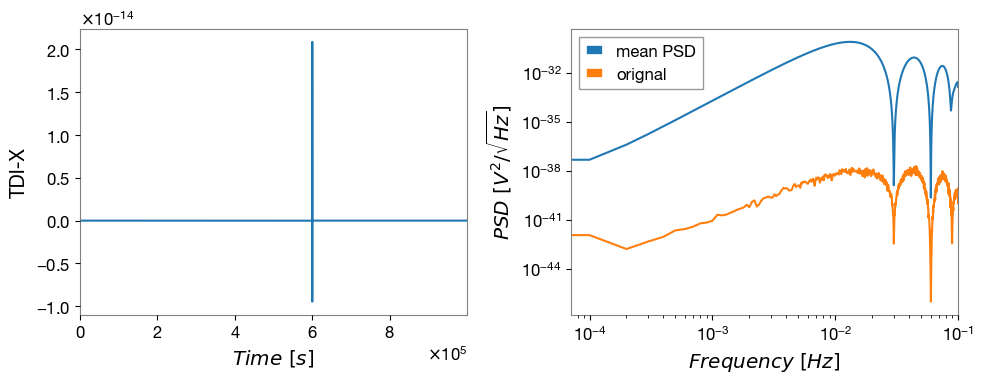

In [24]:
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

tdi_path = getTdiPath('glitch_9.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_orig],
    labels= ["mean PSD", "orignal"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

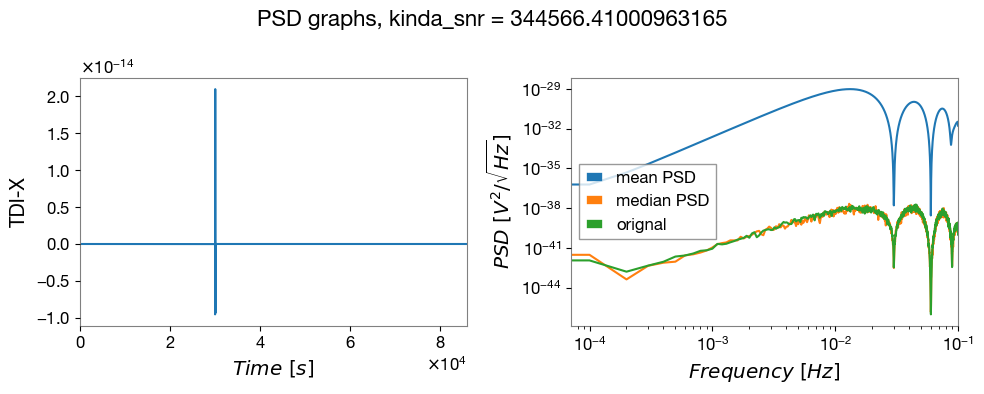

In [22]:
tdi_path = getTdiPath('glitch_9_one_day.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

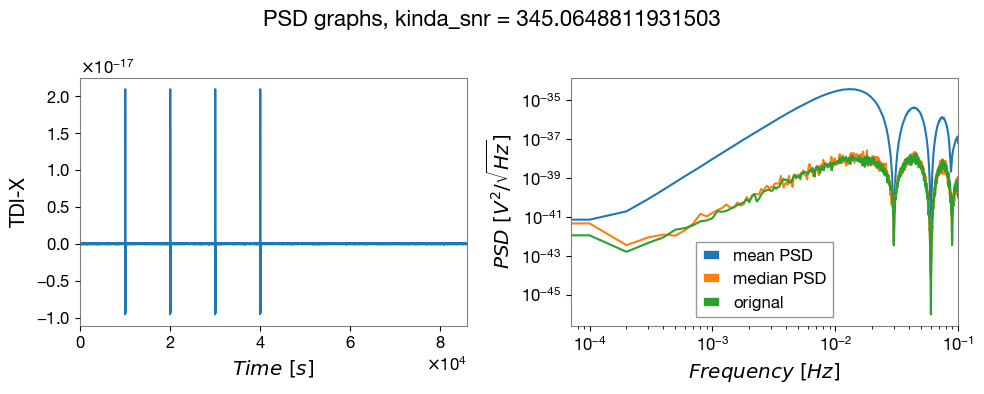

In [24]:
tdi_path = getTdiPath('glitch_7_multiple.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)

In [6]:
tdi_path = getTdiPath('glitch_7_multiple_3.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
delta_t = 1 / fs
idx = nperseg / delta_t
print(idx)

400.0


In [13]:
print(t.size)
print(t)
print(1/fs)
data.size

17200
[0.0000e+00 5.0000e+00 1.0000e+01 ... 8.5985e+04 8.5990e+04
 8.5995e+04]
5.0


17200

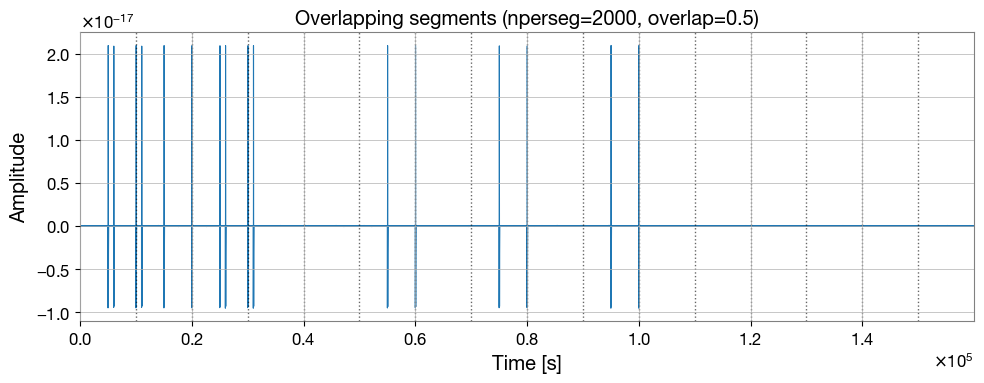

In [29]:
def plot_overlapping_segments(data, nperseg, overlap=0.5, t=None, fs=None, ax=None):
    """
    Plot concatenated overlapping segments from 1D data.
    
    Parameters
    ----------
    data : array-like
        Input signal of length N.
    nperseg : int
        Number of points in each segment.
    overlap : float or int, optional
        If float in (0,1), interpreted as fraction of nperseg.
        If int >= 1, interpreted as number of overlapping points.
        Default is 0.5 (50% overlap).
    t : array-like, optional
        Time vector corresponding to data. Used for x-axis scaling.
    fs : float, optional
        Sampling frequency (Hz). Used if `t` is not provided.
    ax : matplotlib.axes.Axes, optional
        Axes to draw on. If None, creates a new figure and axes.
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        Figure containing the plot.
    ax : matplotlib.axes.Axes
        Axes containing the plot.
    """
    # Determine overlap in points
    if isinstance(overlap, float) and 0 < overlap < 1:
        overlap_pts = int(overlap * nperseg)
    else:
        overlap_pts = int(overlap)
    step = nperseg - overlap_pts

    N = len(data)
    n_segments = (N - overlap_pts) // step
    if n_segments < 1:
        raise ValueError("Not enough data for at least one full segment.")

    # Extract and concatenate segments
    segments = [data[i*step : i*step + nperseg] for i in range(n_segments)]
    concatenated = np.concatenate(segments)

    # Build x-axis
    if t is not None:
        dt = t[1] - t[0]
        x = np.arange(len(concatenated)) * dt
        xlabel = "Time [s]"
    elif fs is not None:
        x = np.arange(len(concatenated)) / fs
        xlabel = "Time [s]"
    else:
        x = np.arange(len(concatenated))
        xlabel = "Sample index"

    # Create plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    else:
        fig = ax.figure
    ax.plot(x, concatenated, lw=0.8)

    # Draw vertical lines at segment boundaries
    for i in range(1, n_segments):
        boundary = i * nperseg
        if t is not None:
            boundary = boundary * dt
        elif fs is not None:
            boundary = boundary / fs
        ax.axvline(boundary, ls=":", lw=1, color="k", alpha=0.6)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Amplitude")
    ax.set_title(f"Overlapping segments (nperseg={nperseg}, overlap={overlap})")
    ax.set_xlim(0, x[-1])
    plt.tight_layout()
    return fig, ax

# Example usage (uncomment when data, t, fs are defined):
tdi_path = getTdiPath('glitch_7_multiple_7.h5')
data, fs, t = readTdi(tdi_path)
fig, ax = plot_overlapping_segments(data, nperseg=2000, overlap=0.5, t=t, fs=fs)
plt.show()

Number of segmetns: 16


/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

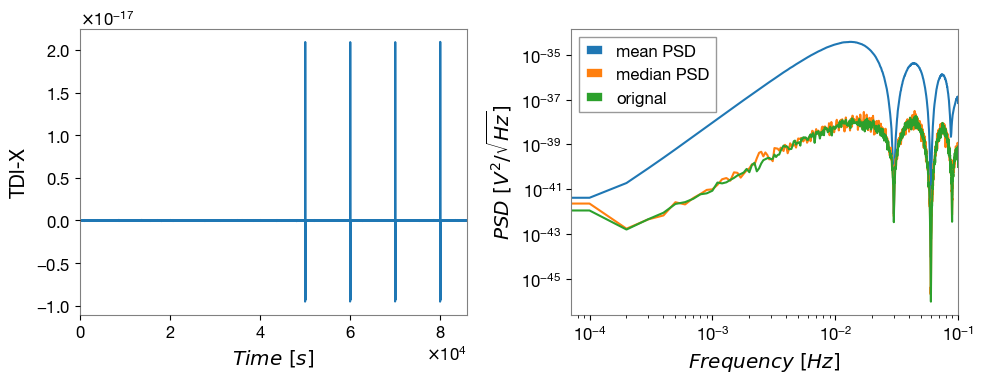

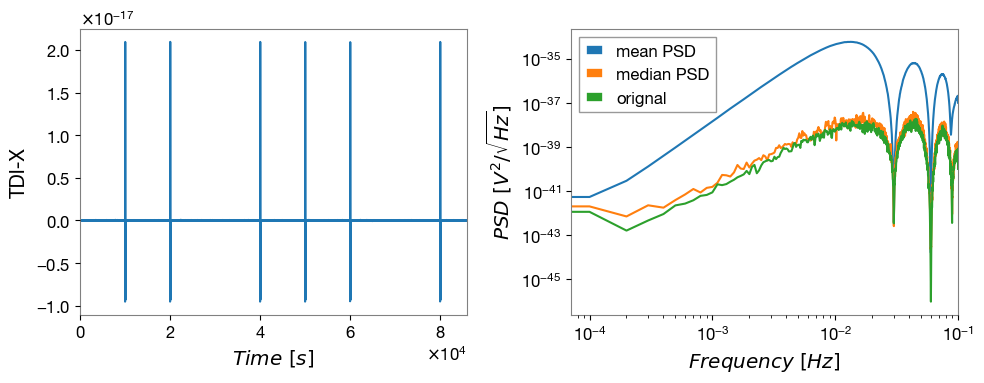

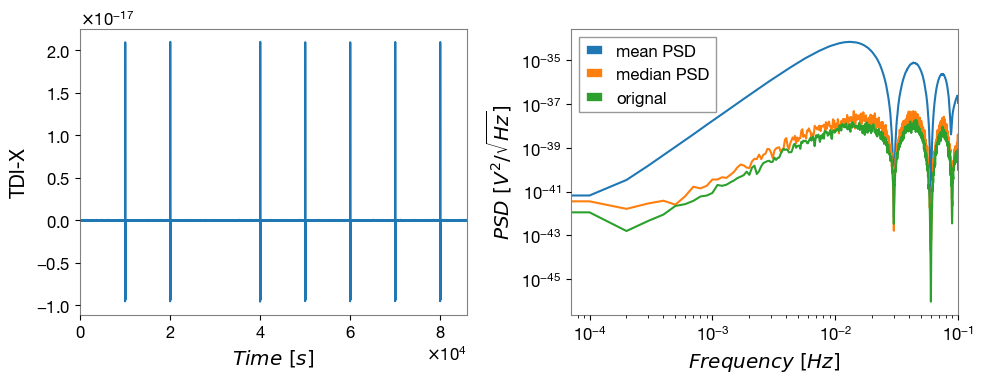

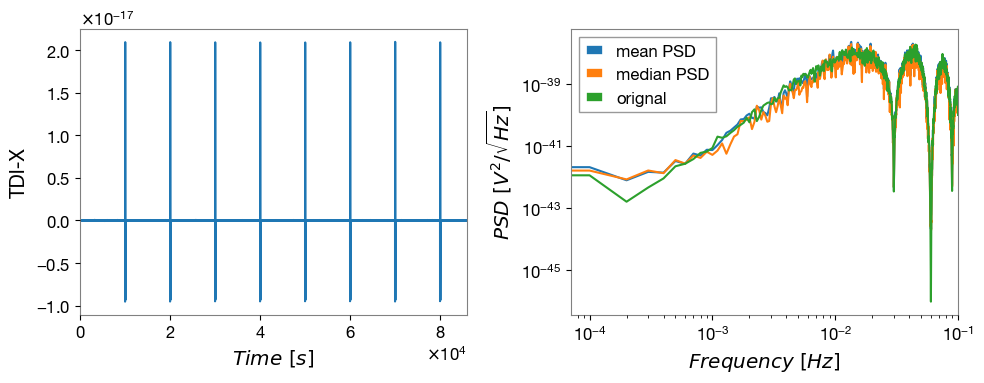

In [24]:
##################################

tdi_path = getTdiPath('glitch_7_multiple_3.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
delta_t = 1 / fs
idx = nperseg / delta_t

f_mean, psd_mean, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
print(f"Number of segmetns: {nseg[0]}")
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
vlines_idx = np.arange(nperseg, len(data), nperseg)
vlines = t[vlines_idx]
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]],
)


#####################################

tdi_path = getTdiPath('glitch_7_multiple_4.h5')
data, fs, t = readTdi(tdi_path)
f_mean, psd_mean, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)



#####################################
tdi_path = getTdiPath('glitch_7_multiple_5.h5')
data, fs, t = readTdi(tdi_path)
f_mean, psd_mean, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)


############################
tdi_path = getTdiPath('glitch_7_multiple_2.h5')
data, fs, t = readTdi(tdi_path)
f_mean, psd_mean, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean",
    noverlap=0
) 
f_median, psd_median, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median",
    noverlap=0
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)

Number of segmetns: 7


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

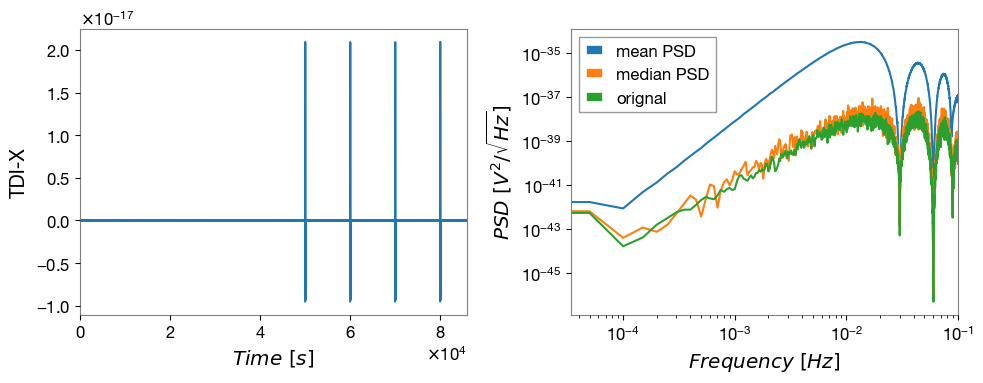

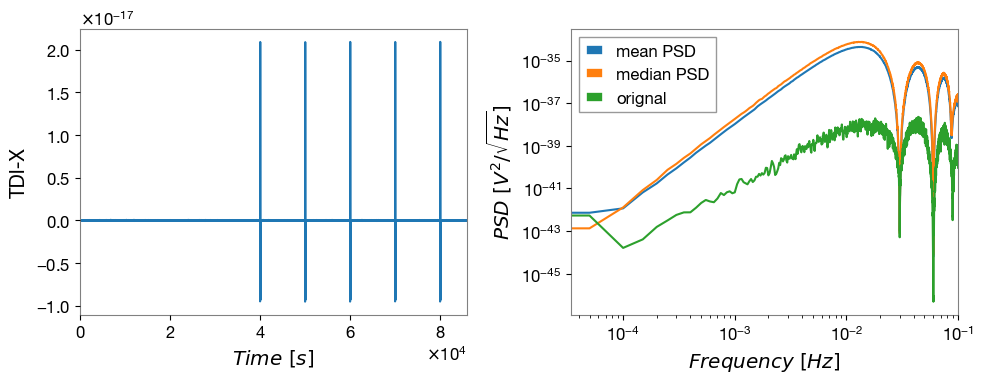

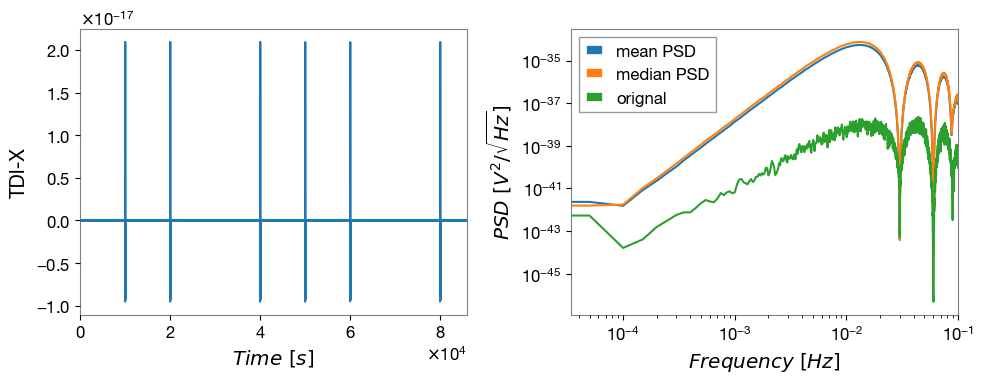

In [22]:
tdi_path = getTdiPath('glitch_1.h5')
data_orig, fs, t = readTdi(tdi_path)

nperseg = 4000
f_orig, psd_orig, _, _ = wosa(
    x=data_orig,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 

##################################

tdi_path = getTdiPath('glitch_7_multiple_3.h5')
data, fs, t = readTdi(tdi_path)
f_mean, psd_mean, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
print(f"Number of segmetns: {nseg[0]}")

f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 

plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)


#####################################

tdi_path = getTdiPath('glitch_7_multiple_6.h5')
data, fs, t = readTdi(tdi_path)
f_mean, psd_mean, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)

##########################################
tdi_path = getTdiPath('glitch_7_multiple_4.h5')
data, fs, t = readTdi(tdi_path)
f_mean, psd_mean, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)

['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17000, 17000, 10200, 6120, 3671, 2203, 1321, 793, 475, 285, 171, 102, 61, 37, 22, 13]
fk_list: [4.705882352941177e-05, 4.705882352941177e-05, 7.843137254901961e-05, 0.00013071895424836603, 0.00021792427131571779, 0.00036314117113027687, 0.0006056018168054504, 0.001008827238335435, 0.0016842105263157896, 0.002807017543859649, 0.004678362573099415, 0.00784313725490196, 0.013114754098360656, 0.021621621621621623, 0.03636363636363636, 0.06153846153846154]
['L_1', 'L_1', '(0.6)^1 L_1', '(0.6)^2 L_1', '(0.6)^3 L_1', '(0.6)^4 L_1', '(0.6)^5 L_1', '(0.6)^6 L_1', '(0.6)^7 L_1', '(0.6)^8 L_1', '(0.6)^9 L_1', '(0.6)^10 L_1', '(0.6)^11 L_1', '(0.6)^12 L_1', '(0.6)^13 L_1', '(0.6)^14 L_1', '(0.6)^15 L_1']
Lk_list: [17000, 17000, 10200, 6120, 3671,

/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

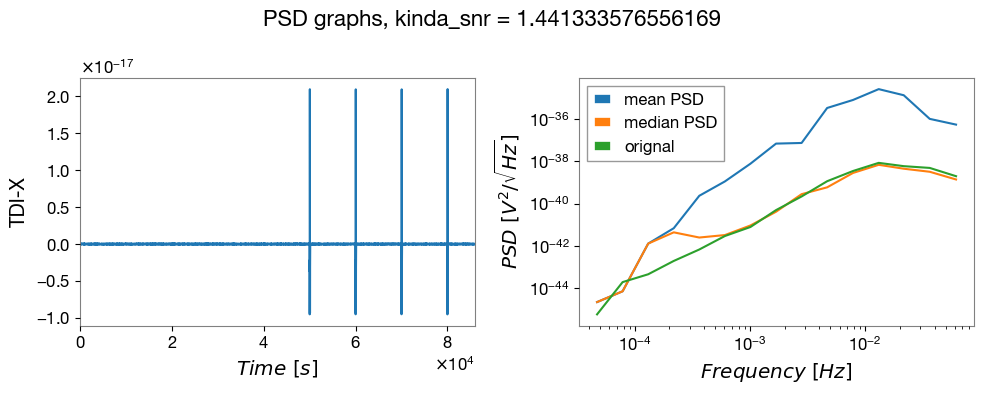

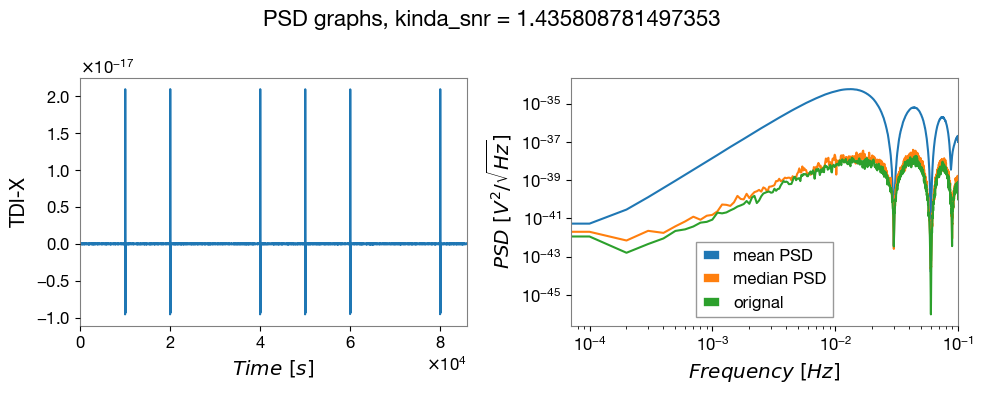

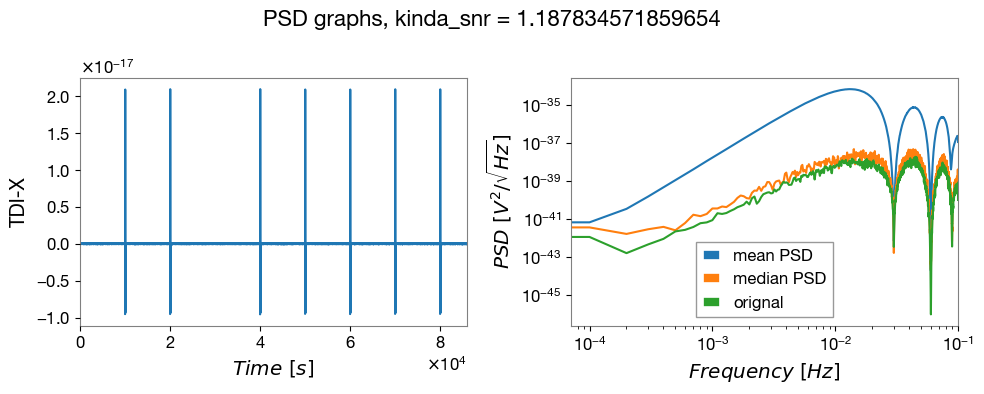

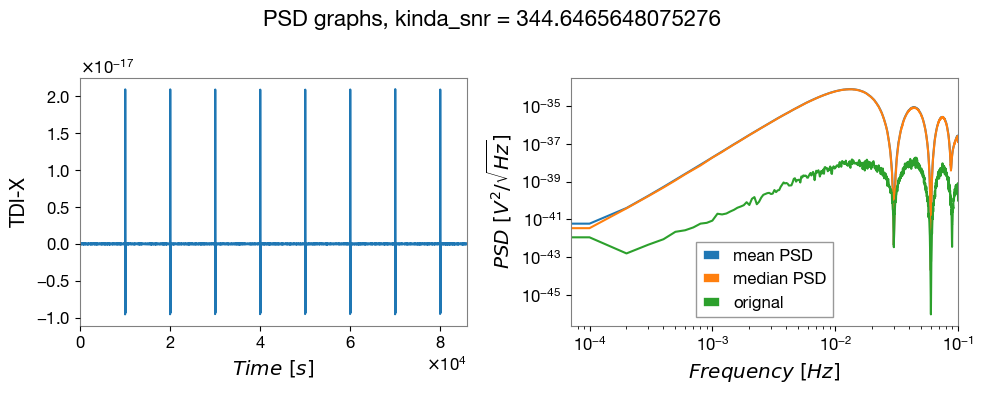

In [12]:

##################################

tdi_path = getTdiPath('glitch_7_multiple_3.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_logpsd, psd_logpsd, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17000
) 
f_logpsd_median, psd_logpsd_median, _ = logpsd(
    x=data,
    fs=fs,
    overlap=0, 
    L1=17000, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_logpsd, 
    psd= [psd_logpsd, psd_logpsd_median, psd_orig_logpsd],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)


#####################################

tdi_path = getTdiPath('glitch_7_multiple_4.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)



#####################################
tdi_path = getTdiPath('glitch_7_multiple_5.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)


############################
tdi_path = getTdiPath('glitch_7_multiple_2.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}",
    f_lims = [f_mean[0], f_mean[-1]]
)


/Users/akmdgreat/anaconda3/envs/bethenv/lib/python3.11/site-packages/gwpy/plot/axes.py:78: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  return func(self, **kw)


(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: xlabel='$Time \\ [s]$', ylabel='TDI-X'>,
        <Axes: xlabel='$Frequency \\ [Hz]$', ylabel='$PSD \\ [V^2/\\sqrt{Hz}]$'>],
       dtype=object))

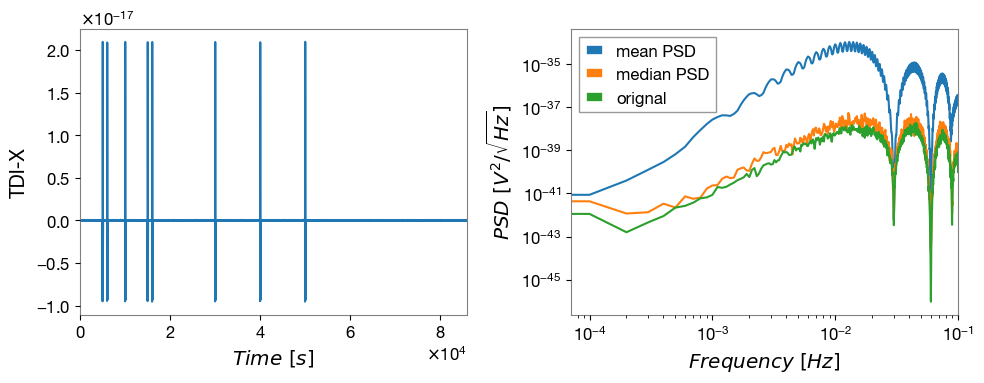

In [28]:
tdi_path = getTdiPath('glitch_7_multiple_7.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
plot(
    data=data,
    t=t, 
    f=f_mean, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    f_lims = [f_mean[0], f_mean[-1]]
)



(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

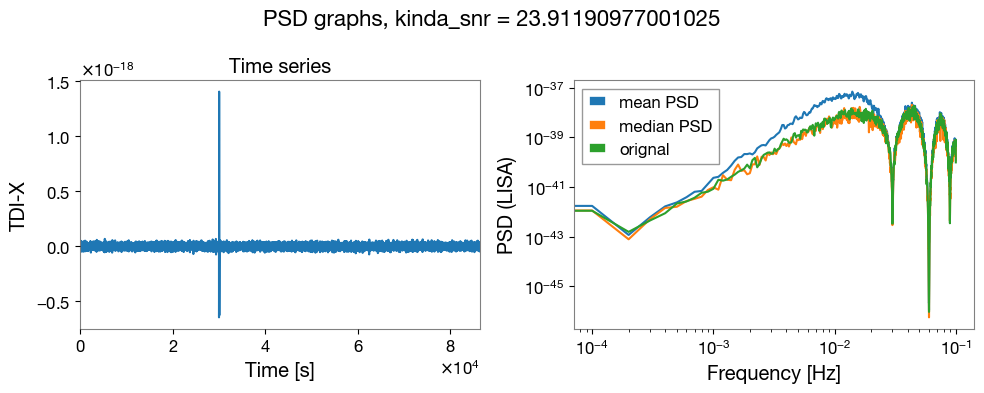

In [ ]:
tdi_path = getTdiPath('glitch_4.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

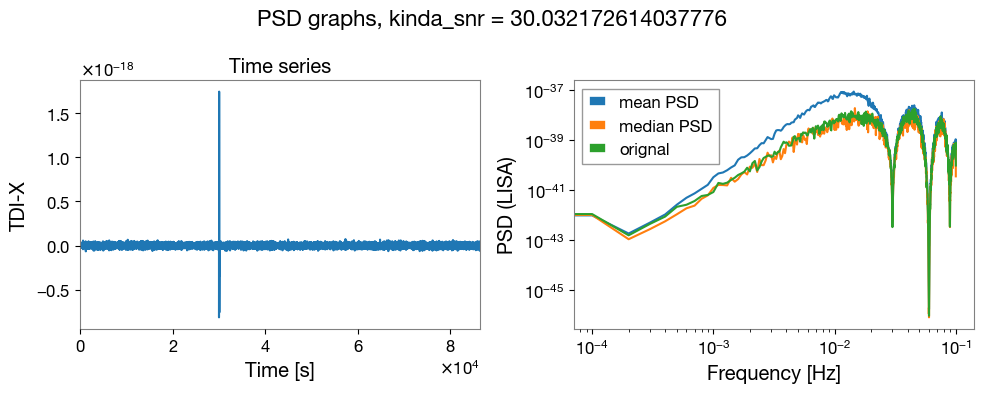

In [ ]:
tdi_path = getTdiPath('glitch_5.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

(<Figure size 1000x400 with 2 Axes>,
 array([<Axes: title={'center': 'Time series'}, xlabel='Time [s]', ylabel='TDI-X'>,
        <Axes: xlabel='Frequency [Hz]', ylabel='PSD (LISA)'>],
       dtype=object))

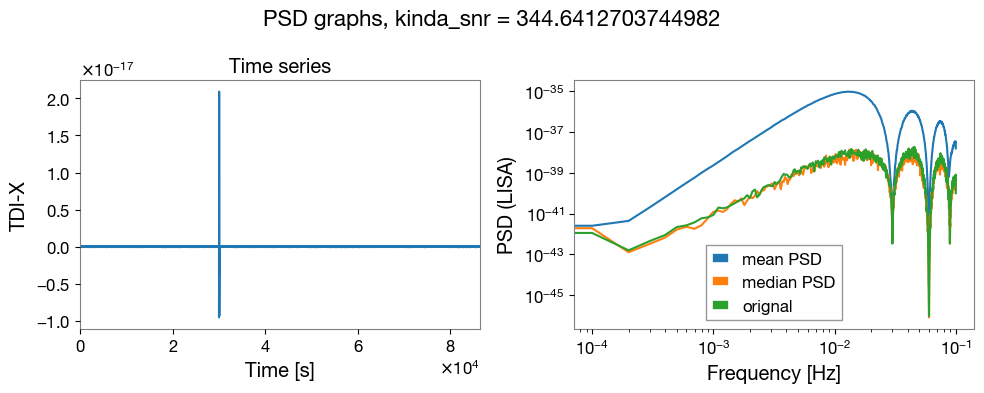

In [ ]:
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

In [ ]:
tdi_path = getTdiPath('glitch_6.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 2000
f_mean, psd_mean, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=2*nseg
)

NameError: name 'dx' is not defined

In [ ]:
# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    psd_orig, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)
f_noise, noise_psds, nseg = n_noise_psds(
    time_noises, 
    fs, 
    nperseg, 
    noverlap=50, 
    window='hann'
)

psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)


In [ ]:
tdi_path = getTdiPath('glitch_7.h5')
data, fs, t = readTdi(tdi_path)
nperseg = 5000
f_mean, psd_mean, _, nseg = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="mean"
) 
f_median, psd_median, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg, 
    method="median"
) 
glitch_integral = np.trapz(np.abs(data[6000-20: 6000+20]), dx=dx)
plot(
    data=data,
    t=t, 
    fs=fs, 
    f=f_mean, 
    nper=nperseg, 
    psd= [psd_mean, psd_median, psd_orig],
    labels= ["mean PSD", "median PSD", "orignal"],
    title="TDI-X", 
    bigtitle=f"PSD graphs, kinda_snr = {glitch_integral / no_glitch_integral}"
)

NameError: name 'dx' is not defined

In [ ]:
print(nseg[0])

16
